Found 7750 images belonging to 2 classes.
Found 328 images belonging to 2 classes.
Found 780 images belonging to 2 classes.


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.8385 - loss: 0.3823 - val_accuracy: 0.8963 - val_loss: 0.2234
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 227s 935ms/step - accuracy: 0.9260 - loss: 0.1781 - val_accuracy: 1.0000 - val_loss: 0.1212
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 224s 922ms/step - accuracy: 0.9404 - loss: 0.1491 - val_accuracy: 0.8963 - val_loss: 0.1380
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 224s 919ms/step - accuracy: 0.9517 - loss: 0.1335 - val_accuracy: 0.8811 - val_loss: 0.2406
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 223s 918ms/step - accuracy: 0.9525 - loss: 0.1225 - val_accuracy: 1.0000 - val_loss: 0.0728
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 225s 926ms/step - accuracy: 0.9560 - loss: 0.1174 - val_accuracy: 1.0000 - val_loss: 0.0900
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 225s 924ms/step - accuracy: 0.9626 - loss: 0.1012 - val_accuracy: 0.8963 - val_loss: 0.1090
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 225s 925ms/step - accuracy: 0.9564 - lo

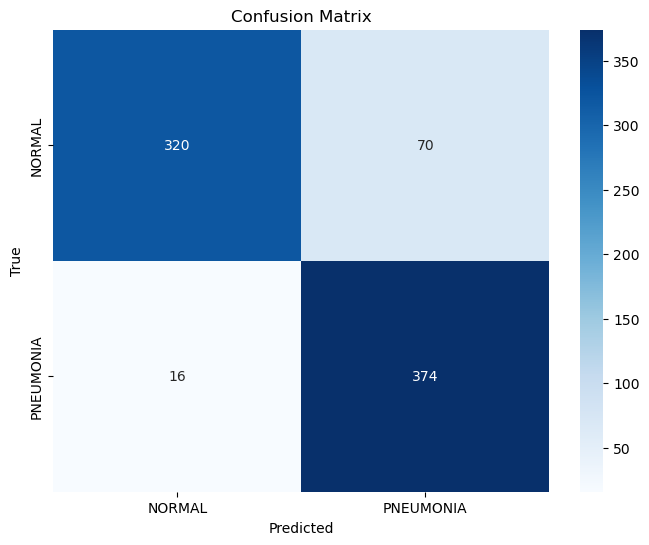

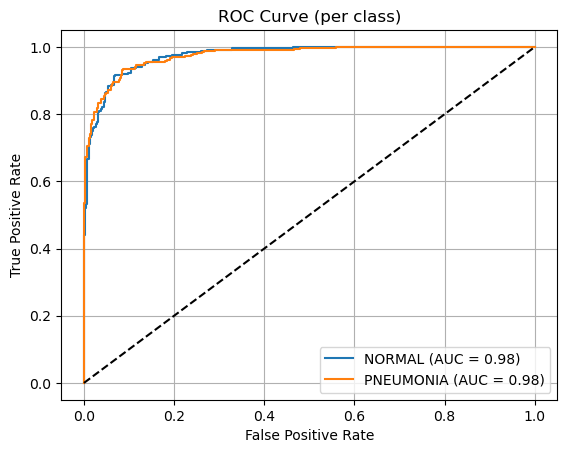

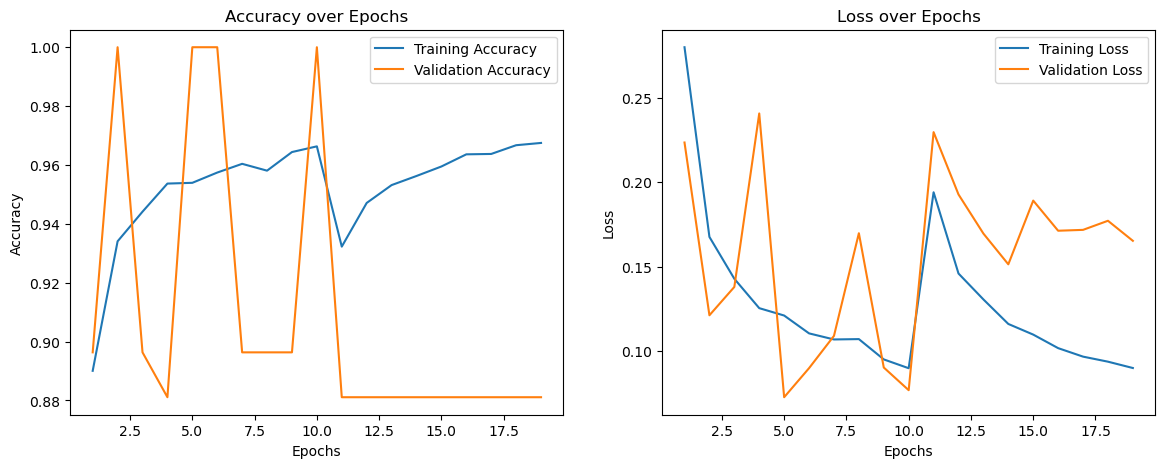

In [5]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=15,
                                   zoom_range=0.1,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(train_gen.num_classes, activation='softmax')
])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_1 = model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=[early_stop])

# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
history_2 = model.fit(train_gen, validation_data=val_gen, epochs=15, callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])

In [7]:
import matplotlib.pyplot as plt

fig_dir = 'D:/Data-Chest-ray'
os.makedirs(fig_dir, exist_ok=True)

# Courbe d'apprentissage
def save_learning_curves(history_list, save_path):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.savefig(os.path.join(save_path, 'learning_curves.png'))
    plt.close()

save_learning_curves([history_1, history_2], fig_dir)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'))
plt.close()
plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'roc_curve.png'))
plt.close()



In [9]:
# save
model_save_path = 'D:/Data-Chest-ray'
os.makedirs(model_save_path, exist_ok=True)

# Sauvegarder le modèle final
model.save(os.path.join(model_save_path, 'EfficientNetB0perfect_finetuned.keras'))
print("✅ Modèle enregistré avec succès dans pc.")

✅ Modèle enregistré avec succès dans pc.


Found 7750 images belonging to 2 classes.
Found 328 images belonging to 2 classes.
Found 780 images belonging to 2 classes.


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 242s 968ms/step - accuracy: 0.7175 - loss: 0.5413 - val_accuracy: 0.8963 - val_loss: 0.3543
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 233s 958ms/step - accuracy: 0.9075 - loss: 0.2531 - val_accuracy: 0.9268 - val_loss: 0.2268
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 229s 941ms/step - accuracy: 0.9280 - loss: 0.1923 - val_accuracy: 1.0000 - val_loss: 0.1475
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 229s 940ms/step - accuracy: 0.9281 - loss: 0.1786 - val_accuracy: 1.0000 - val_loss: 0.1317
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 233s 959ms/step - accuracy: 0.9373 - loss: 0.1701 - val_accuracy: 1.0000 - val_loss: 0.0922
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 240s 988ms/step - accuracy: 0.9437 - loss: 0.1463 - val_accuracy: 0.8811 - val_loss: 0.1612
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 238s 980ms/step - accuracy: 0.9505 - loss: 0.1408 - val_accuracy: 1.0000 - val_loss: 0.0656
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.9463 - lo

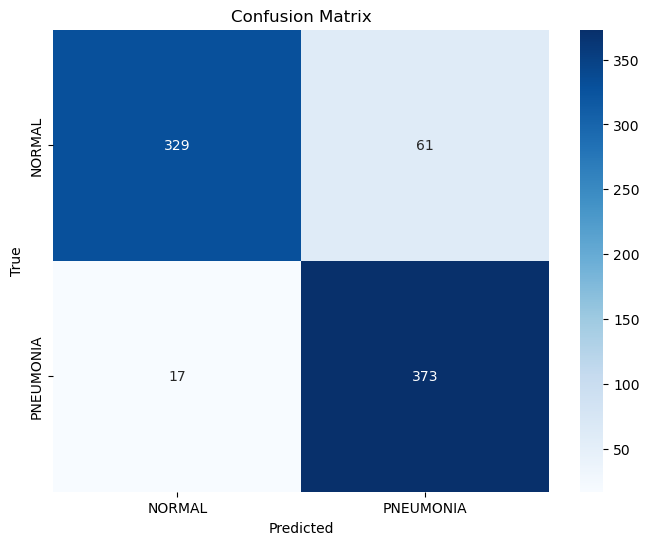

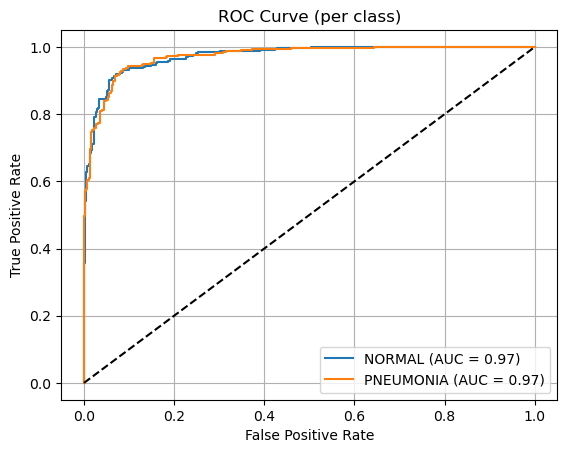

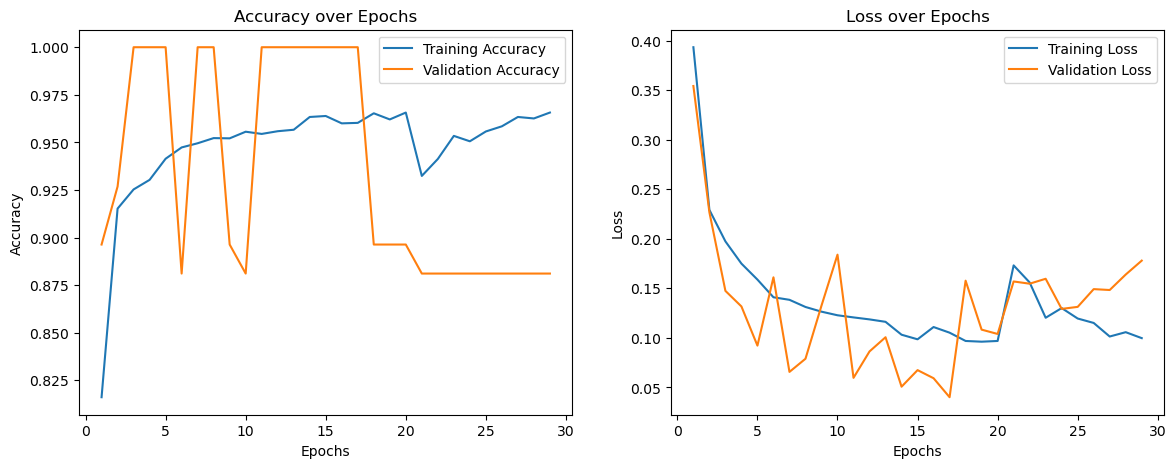

In [11]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=15,
                                   zoom_range=0.1,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation='softmax')
])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_1 = model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=[early_stop])

# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
history_2 = model.fit(train_gen, validation_data=val_gen, epochs=15, callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])


Found 7750 images belonging to 2 classes.
Found 328 images belonging to 2 classes.
Found 780 images belonging to 2 classes.


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 418s 2s/step - accuracy: 0.6551 - loss: 0.6998 - val_accuracy: 0.8232 - val_loss: 0.3654
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.8522 - loss: 0.3469 - val_accuracy: 0.9268 - val_loss: 0.2879
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 1180s 5s/step - accuracy: 0.8928 - loss: 0.2701 - val_accuracy: 0.9268 - val_loss: 0.2377
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 300s 1s/step - accuracy: 0.9044 - loss: 0.2422 - val_accuracy: 1.0000 - val_loss: 0.1968
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9163 - loss: 0.2316 - val_accuracy: 1.0000 - val_loss: 0.1640
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9162 - loss: 0.2096 - val_accuracy: 1.0000 - val_loss: 0.1537
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9320 - loss: 0.1858 - val_accuracy: 0.8963 - val_loss: 0.1675
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.9333 - loss: 0.1819 - val_acc

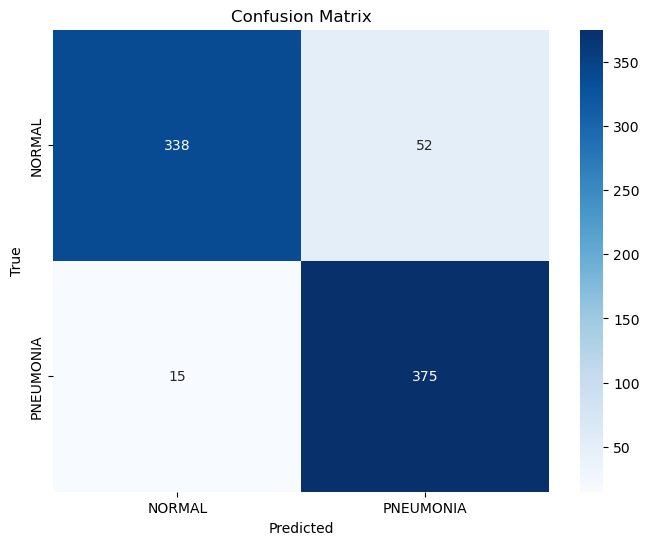

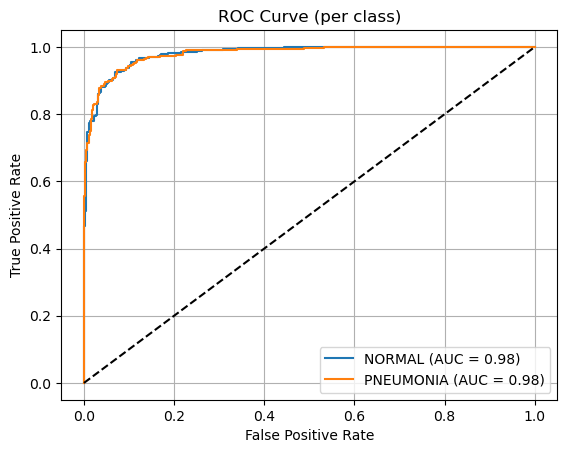

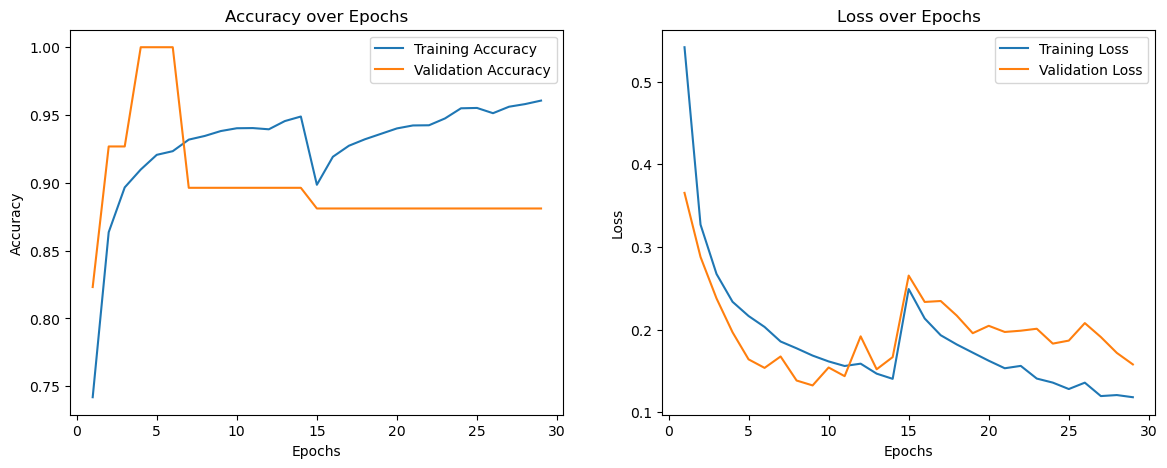

In [5]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=15,
                                   zoom_range=0.1,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.7),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.7),
    layers.Dense(train_gen.num_classes, activation='softmax')
])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_1 = model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=[early_stop])

# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
history_2 = model.fit(train_gen, validation_data=val_gen, epochs=15, callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])

In [7]:
for i, label in enumerate(target_names):
    class_indices = np.where(y_true == i)[0]
    class_y_pred = y_pred[class_indices]
    class_y_true = y_true[class_indices]
    class_f1 = f1_score(class_y_true, class_y_pred, average='macro')
    acc = np.mean(class_y_pred == class_y_true)
    print(f"🔍 Classe: {label} — Accuracy: {acc:.2f}, F1-score: {class_f1:.2f}")


🔍 Classe: NORMAL — Accuracy: 0.87, F1-score: 0.46
🔍 Classe: PNEUMONIA — Accuracy: 0.96, F1-score: 0.49


In [9]:
import matplotlib.pyplot as plt

fig_dir = 'D:/Data-Chest-ray'
os.makedirs(fig_dir, exist_ok=True)

# Courbe d'apprentissage
def save_learning_curves(history_list, save_path):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.savefig(os.path.join(save_path, 'learning_curves.png'))
    plt.close()

save_learning_curves([history_1, history_2], fig_dir)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'))
plt.close()
plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'roc_curve.png'))
plt.close()


In [11]:
# save
model_save_path = 'D:/Data-Chest-ray'
os.makedirs(model_save_path, exist_ok=True)

# Sauvegarder le modèle final
model.save(os.path.join(model_save_path, 'EfficientNetB00.7perfect_finetuned.keras'))
print("✅ Modèle enregistré avec succès dans pc.")

✅ Modèle enregistré avec succès dans pc.
